# Setup

In [57]:
from pathlib import Path
import sys

sys.path.append(str(Path.cwd().parent))
from stat_test_tools import *

descriptions = {
    "max_fit": "Fitness (max fitness)",
    "div": "Behavioral diversity"
}

container_naming = {
    "add_novelty": "inc. fitness",
    "sub_novelty": "inc. novelty",
    "novelty": "pure novelty",
    "novelty_archiving": "novelty archive",
    "novelty_limit": "limit archive",
    "fit_archiving": "fit. archive",
    "elite_archiving": "elite archive",
    "fitness":"fitness"
}

env_naming = {
    "lunarlander": "Lunar Lander",
    "cartpole": "CartPole"
}

alg_naming = {
    "lambda": "ES",
    "diff": "DE"
}

hyperparameter_naming = {
    "m": "$\lambda$",
    "l": "$\mu$",
    "mutation_sigma": "$\sigma$",
    "archive_batch": "arch. batch",
    "archiving_period": "arch. T",
    "cross_method": "method",
    "fitness_weight":"$W_0$",
    "decay":"$r_D$",
    "cross_uni": "$p_U$"
}

datasets = {"cartpole":"server_try0", "lunarlander":"server_try3"}

def table_to_latex(dk):
    dk = dk.replace(["NaN", "nan", None], np.nan)
    new_columns = [hyperparameter_naming[col] if col in hyperparameter_naming else col for col in dk.columns]
    dk.columns = new_columns
    index = [container_naming[col] if col in container_naming else col for col in dk.index]
    dk.index = index
    dk=dk.fillna("-")
    if "method" in dk.columns:
        dk["method"] = dk["method"].apply(lambda x: "A" if x =="mean" else "U")
    latex = dk.to_latex(
        index=True,
        escape=False,
        formatters= [fmt] * len(dk.columns),
        column_format="l" + "c" * len(dk.columns)
    )
    return latex
def fmt(x):
    if pd.isna(x):
        return "-"
    if isinstance(x, (int, float)):
        if x == 0:
            return "0"
        elif abs(x) < 1e-3:
            mantissa, exp = f"{x:.3e}".split("e")
            return rf"$\mathbf{{{mantissa} \times 10^{{{int(exp)}}}}}$"
        else:
            if x < 0.05:
                return rf"$\textbf{{{x:.3f}}}$"
            return f"{x:.3f}"
    if x in container_naming:
        return container_naming[x]
    return str(x)


def fmt_no_highlight(x):
    if pd.isna(x):
        return "-"
    if isinstance(x, (int, float)):
        if x == 0:
            return "0"
        elif abs(x) < 1e-3:
            mantissa, exp = f"{x:.2e}".split("e")
            return rf"${{mantissa}}\times 10^{{{int(exp)}}}$"
        else:
            return f"{x:.2f}"
    if x in container_naming:
        return container_naming[x]
    return str(x)

# Grid protocols

In [58]:
ens = ["lunarlander", "cartpole"]
grid_datasets = {"cartpole":"server_try0", "lunarlander":"server_try2"}
for en in ens:
    for alg in ["lambda", "diff"]:
        df = get_protocol_table(en, alg, grid_datasets[en], path="../Data/grid_search/" )
        df.to_csv(f"../Data/grid_protocol/{en}_{alg}.csv")
dk = df["origin"].copy()
dk


Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
[{'crossmethod': 'uniform', 'lambda': 70, 'mu': 50, 'mutation_rate': 0.02, 'cross_rate': 0.5, 'sigma': 2.5, 'archiving_period': 5, 'archive_batch': 4, 'limit': -90.0, 'cross': 0.5}]
{'cross_method': 'uniform', 'l': 55, 'm': 50, 'mr': 0.02, 'cr': 0.6, 'mutation_sigma': 2.5, 'archiving_period': 5, 'archive_batch': 4, 'limit': -90.0, 'cross_uni': 0.5}
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
[{'lambda': 50, 'mutation_rate': 0.8, 'cross_rate': 0.8, 'archiving_period': 2, 'archive_batch': 1, 'limit': -180.0}]
{'l': 60, 'mr': 0.9, 'cr': 0.8, 'archiving_period': 2, 'archive_batch': 1, 'limit': -180.0}
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
[{'crossmethod': 'uniform', 'lambda': 20, 'mu': 30, 'mutation_rate': 0.06, 'cro

,archive_batch,archiving_period,cr,decay,fitness_weight,l,limit,mr
fitness,NaN,NaN,1.0,NaN,NaN,15.0,NaN,0.5
novelty,NaN,NaN,1.0,NaN,NaN,20.0,NaN,0.8
add_novelty,NaN,NaN,0.9,2.5,1.0,10.0,NaN,1.0
sub_novelty,NaN,NaN,1.0,3.5,0.4,10.0,NaN,0.7
fit_archiving,3.0,3.0,0.9,NaN,NaN,20.0,NaN,0.9
elite_archiving,4.0,2.0,0.5,NaN,NaN,20.0,NaN,0.8
novelty_archiving,3.0,3.0,0.8,NaN,NaN,15.0,NaN,0.6
novelty_limit,3.0,3.0,1.0,NaN,NaN,20.0,240.0,0.9


In [59]:
from tabulate import tabulate
en = "lunarlander"
alg = "lambda"
df2 = pd.read_csv(f"../Data/grid_protocol/{en}_{alg}.csv", header=[0,1], index_col=[0])
if alg =="lambda":
       df2=df2.drop([("final","cross_method"), ("origin", "cross_method")], axis=1)
delta =  df2["final"] - df2["origin"]
delta = delta.loc[~(delta.fillna(0) == 0).all(axis=1)]
mask = ~delta.fillna(0).eq(0).all(axis=0)
delta = delta.loc[:, mask]
delta= delta.replace({0:"-"})
latex = table_to_latex(delta)
print(latex)

\begin{tabular}{lcccc}
\toprule
{} &   cr &               $\mu$ &           $\lambda$ &    mr \\
\midrule
pure novelty    & -0.1 &                   - &                   - &     - \\
inc. fitness    &    - &              15.000 &                   - &     - \\
inc. novelty    &  0.1 &                   - &  $\textbf{-15.000}$ &  0.05 \\
fit. archive    &    - &              30.000 &              15.000 &   0.1 \\
elite archive   & -0.1 &                   - &              15.000 &   0.1 \\
novelty archive & -0.1 &              15.000 &              15.000 &     - \\
limit archive   &  0.1 &  $\textbf{-15.000}$ &                   - &     - \\
\bottomrule
\end{tabular}



/tmp/ipykernel_76612/4092542247.py:56: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex = dk.to_latex(


In [60]:

#delta = delta.loc[~(delta.fillna(0) == 0).all()]
# mask = ~delta.fillna(0).eq(0).all(axis=0)
# delta = delta.loc[:, mask]

# delta.to_csv(f"./Data/grid_protocol/delta_{en}_{alg}.csv")


latex = table_to_latex(dk)
print(latex)

\begin{tabular}{lcccccccc}
\toprule
{} & arch. batch & arch. T &    cr & $r_D$ & $W_0$ &  $\mu$ &  limit &    mr \\
\midrule
fitness         &           - &       - & 1.000 &     - &     - & 15.000 &      - & 0.500 \\
pure novelty    &           - &       - & 1.000 &     - &     - & 20.000 &      - & 0.800 \\
inc. fitness    &           - &       - & 0.900 &   2.5 &   1.0 & 10.000 &      - & 1.000 \\
inc. novelty    &           - &       - & 1.000 &   3.5 &   0.4 & 10.000 &      - & 0.700 \\
fit. archive    &         3.0 &     3.0 & 0.900 &     - &     - & 20.000 &      - & 0.900 \\
elite archive   &         4.0 &     2.0 & 0.500 &     - &     - & 20.000 &      - & 0.800 \\
novelty archive &         3.0 &     3.0 & 0.800 &     - &     - & 15.000 &      - & 0.600 \\
limit archive   &         3.0 &     3.0 & 1.000 &     - &     - & 20.000 &  240.0 & 0.900 \\
\bottomrule
\end{tabular}



/tmp/ipykernel_76612/4092542247.py:56: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex = dk.to_latex(


# Gens graph

Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!


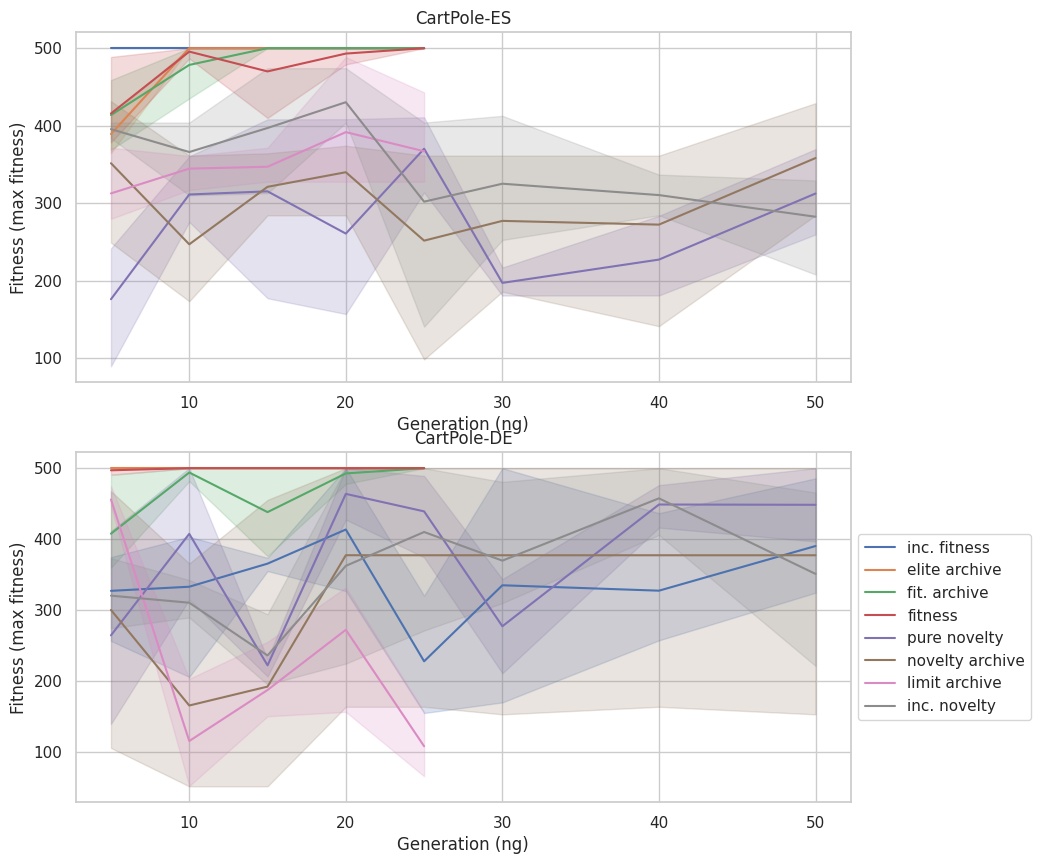

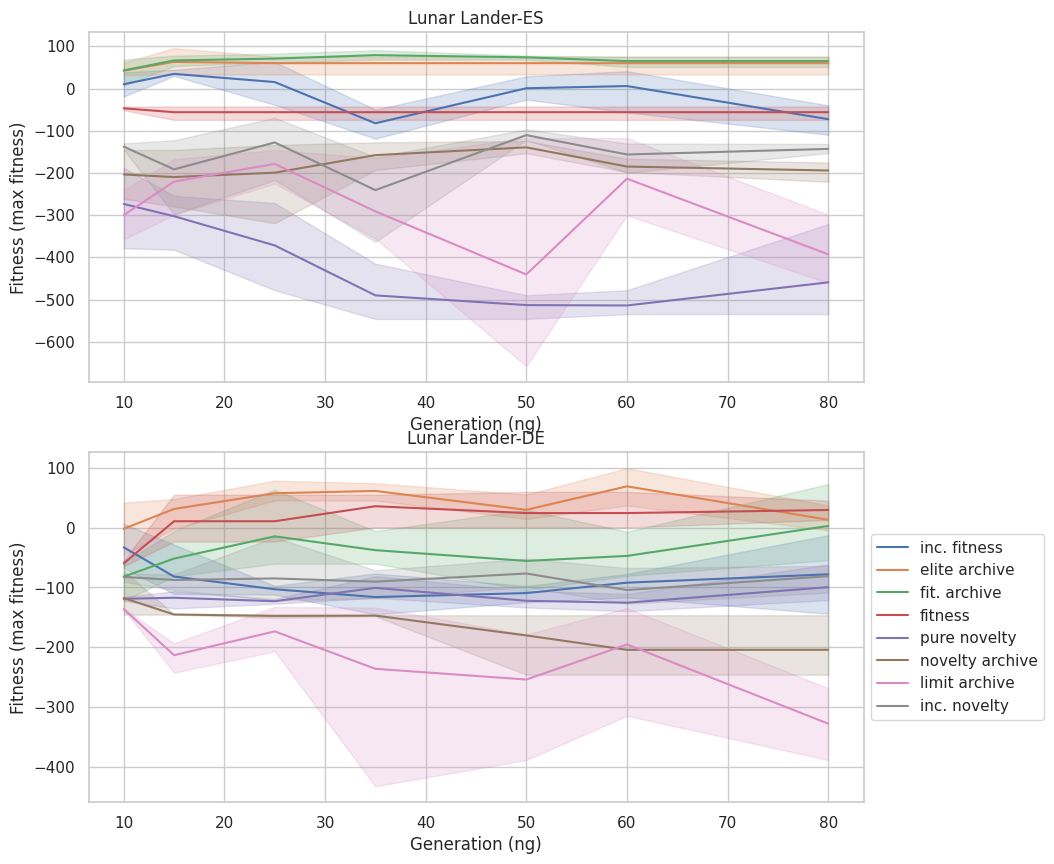

In [61]:

from libs import constants as cst
import matplotlib.pyplot as plt
en = "lunarlander"
alg = "diff"
names = {"lunarlander":"server_try3", "cartpole":"server_try0"}

def create_figures(names, attr):
    path = "../Docs/vzor-dp/img/"
    for en in cst.ENIVROMENTS:
        fig,axes = plt.subplots(2,1,figsize=(10, 10))
        for i, alg in enumerate(["lambda", "diff"]):
            #plt.figure()
            ax = plot_generations(en=en, alg=alg, name=names[en], attr=attr, ax=axes[i], path="../Data/generation_ex/")
            handles, labels = ax.get_legend_handles_labels()
            new_labels = [container_naming[l] for l in labels]
            ax.legend_.remove()
            ax.set_xlabel("Generation (ng)")
            ax.set_ylabel(descriptions[attr])
            ax.set_title(f"{env_naming[en]}-{alg_naming[alg]}")

        plt.legend(handles, new_labels, loc="center left", bbox_to_anchor=(1, 0.5))
        plt.savefig(path + f"generations_{en}_{attr}.pdf", bbox_inches="tight")

create_figures(names, "max_fit")

In [62]:
print(df.columns.tolist())

[('final', 'archive_batch'), ('final', 'archiving_period'), ('final', 'cr'), ('final', 'decay'), ('final', 'fitness_weight'), ('final', 'l'), ('final', 'limit'), ('final', 'mr'), ('origin', 'archive_batch'), ('origin', 'archiving_period'), ('origin', 'cr'), ('origin', 'decay'), ('origin', 'fitness_weight'), ('origin', 'l'), ('origin', 'limit'), ('origin', 'mr')]


In [63]:
df = gen_extract_values(load_gen_direct_data("cartpole", "fitness", "lambda", "server_try0", path="../Data/generation_ex/"))
df.groupby("ng").median()

Found 1 files!


/tmp/ipykernel_76612/17495369.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df.groupby("ng").median()


,max_fit,avg_fit,median_fit,min_fit,std_fit,div
ng,,,,,,
5,380.0,248.844444,182.166667,38.333333,137.925233,0.547401
10,500.0,320.355556,380.000000,23.666667,150.994717,0.391541
15,500.0,238.411111,181.500000,14.166667,152.964761,0.386958
20,500.0,215.944444,245.666667,9.833333,136.345529,0.549736
25,500.0,223.366667,224.000000,25.500000,144.079880,0.527765


# Statistical tests

## Algorithms

In [64]:
total = wilcoxon_test_total_algorithms(datasets, "fitnesses")
total

(89642.0, 0.03870676244646096)

In [65]:
ll_wilcoxon = wilcoxon_test_per_environment_algorithms("lunarlander",datasets, "fitnesses")
carpole_wilcoxon = wilcoxon_test_per_environment_algorithms("cartpole",datasets, "fitnesses")

-54.22316957560915
29.124999999999996


In [66]:
ll_wilcoxon

(18713.0, 3.113835150920772e-12, -54.22316957560915)

In [67]:
carpole_wilcoxon

(13428.0, 0.0002129582820475215, 29.124999999999996)

## Containers

### Friedman

In [68]:
f_c = friedman_test_per_environment_containers("cartpole", datasets, "fitnesses")
f_l =friedman_test_per_environment_containers("lunarlander", datasets, "fitnesses")
print(f_c)
print(f_l)

FriedmanchisquareResult(statistic=326.65791750793215, pvalue=1.2158324856403088e-66)
FriedmanchisquareResult(statistic=328.39150568933593, pvalue=5.177754695041798e-67)


In [69]:
f_c = friedman_test_per_environment_containers("cartpole", datasets, "behaviors")
f_l =friedman_test_per_environment_containers("lunarlander", datasets, "behaviors")
print(f_c)
print(f_l)

FriedmanchisquareResult(statistic=163.91859695565856, pvalue=4.7999219391876454e-32)
FriedmanchisquareResult(statistic=257.6160485502362, pvalue=6.623871835058549e-52)


### Wilcoxon

In [70]:
def wilcoxon_to_latex(dk, contestant_names):
    dk = dk.copy()

    if "direction"  in dk and "holm_reject" in dk:
        dk["Conclusion"] = dk["holm_reject"].apply(lambda x: "rejected" if x else "sustained")
        dk["direction"] = dk[["holm_reject", "direction"]].apply(lambda x: x["direction"] if x["holm_reject"] else "-", axis=1)
    dk["contestant1"] = dk["contestant1"].apply(lambda x: contestant_names[x])
    dk["contestant2"] = dk["contestant2"].apply(lambda x: contestant_names[x])

    COLUMN_NAMES = {
        "direction":"${HL}_{Total}$",
        "direction_diff":"${HL}_{DE}$",
        "direction_lambda":"${HL}_{ES}$",
        "hoch_p": "$p_{Hoch}$",
        "holm_p": "$p_{Holm}$",
        "wilcoxon_T": "$W_T$",
        "contestant1": "A",
        "contestant2": "B",
        "p_adj": "$p_{Total}$",
        "p_adj_diff": "$p_{DE}$",
        "p_adj_lambda": "$p_{ES}$"

    }

    new_columns = [COLUMN_NAMES[col] if col in COLUMN_NAMES else col for col in dk.columns]
    dk.columns = new_columns

    if "hoch_reject" in dk.columns:
        dk = dk.drop(columns=["holm_reject", "hoch_reject"])
    latex = dk.to_latex(
        index=False,
        escape=False,
        formatters= [fmt if col.startswith("$p") else fmt_no_highlight for col in dk.columns],
        column_format="c" * len(dk.columns)
    )
    return latex

In [71]:

ll_wilcoxon_total = apply_corrections(wilcoxon_test_per_environment_containers("lunarlander",datasets, "fitnesses"))
def prepare_join(df):
    df = df.copy()
    assert (df["holm_reject"] == df["hoch_reject"]).all()
    df["p_adj"] = df.apply(lambda x: max(x["holm_p"], x["hoch_p"]), axis=1)
    df["direction"] = df.apply(lambda x: "-" if x["p_adj"] > 0.05 else x["direction"], axis=1)
    return df[["contestant1", "contestant2", "direction", "p_adj"]]

In [72]:
def wilcox_table_create(en, datasets, attr):
    wilcoxon_total = prepare_join(apply_corrections(wilcoxon_test_per_environment_containers(en,datasets, attr)))
    wilcoxon_diff = prepare_join(apply_corrections(wilcoxon_test_per_env_alg_containers(en,"diff",datasets, attr)))
    wilcoxon_lambda = prepare_join(apply_corrections(wilcoxon_test_per_env_alg_containers(en,"lambda",datasets, attr)))

    return wilcoxon_total.merge(
        wilcoxon_diff, 
        on=["contestant1", "contestant2"], 
        suffixes=("", "_diff")
        ).merge(
            wilcoxon_lambda,
            on=["contestant1", "contestant2"], 
            suffixes=("", "_lambda")
        )

l = wilcoxon_to_latex(wilcox_table_create("lunarlander", datasets, "fitnesses"), container_naming)
c = wilcoxon_to_latex(wilcox_table_create("cartpole", datasets, "fitnesses"), container_naming)

with open("../Docs/vzor-dp/tables/lunarlander_wilcoxon_fit_conts.tex", "w") as f:
    f.write(l)

with open("../Docs/vzor-dp/tables/cartpole_wilcoxon_fit_conts.tex", "w") as f:
    f.write(c)

/home/schkliba/.pyenv/versions/prometheus/lib/python3.10/site-packages/scipy/stats/_morestats.py:3337: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/tmp/ipykernel_76612/3229357972.py:30: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex = dk.to_latex(
/home/schkliba/.pyenv/versions/prometheus/lib/python3.10/site-packages/scipy/stats/_morestats.py:3337: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/home/schkliba/.pyenv/versions/prometheus/lib/python3.10/site-packa

In [73]:

def comparisons(en, attr):
    table = wilcox_table_create(en, datasets, attr)
    main_df = pd.DataFrame()
    for suf in ["", "_diff", "_lambda"]:
        
        def winning(x):
            if not isinstance(x["direction"+suf], str): 
                if float(x["direction"+suf]) > 0:
                    return x["contestant1"] 
                elif  x["direction"+suf] != 0:
                    return x["contestant2"]
            return "-"
        def losing(x):
            if not isinstance(x["direction"+suf], str): 
                if float(x["direction"+suf]) > 0:
                    return x["contestant2"] 
                elif  x["direction"+suf] != 0:
                    return x["contestant1"]
            return "-"

        table["winner"+suf] = table.apply(
            winning, 
            axis=1)
        table["loser"+suf] = table.apply(
            losing, 
            axis=1)

        wins = table["winner"+suf].value_counts()
        loses = table["loser"+suf].value_counts()
        def summary(x):
            return f"{int(x['winner'+suf])}/{int(x['loser'+suf])}/{int(7 - (x['loser'+suf]+x['winner'+suf]))}"

        df = pd.concat([wins,loses], axis=1)
        summary_t = df.fillna(0).apply(summary, axis=1)
        summary_t.name="summary"+suf
        main_df = pd.concat([main_df,summary_t],axis=1)
    return main_df.drop(index="-")
 

def environment_table(en):
    fit = comparisons(en,"fitnesses")
    div = comparisons(en,"behaviors")

    return fit.merge(div, left_index=True, right_index=True, suffixes=("_fit","_div"))

def e_table_to_latex(dk):
    dk = dk.copy()

    COLUMN_NAMES = {
        "summary_diff_fit":"Fit. DE",
        "summary_lambda_fit":"Fit. ES",
        "summary_fit":"Fit. Sum.",
        "summary_diff_div":"Div. DE",
        "summary_lambda_div":"Div. ES",
        "summary_div":"Div. Sum.",
    }

    new_columns = [COLUMN_NAMES[col] if col in COLUMN_NAMES else col for col in dk.columns]
    dk.columns = new_columns
    dk.index = [container_naming[i] for i in dk.index]
    latex = dk.to_latex(
        index=True,
        escape=False,
        column_format="l|ccc|ccc"
    )
    return latex

l = e_table_to_latex(environment_table("lunarlander"))
c = e_table_to_latex(environment_table("cartpole"))

with open("../Docs/vzor-dp/tables/lunarlander_wilcoxon_summary.tex", "w") as f:
    f.write(l)

with open("../Docs/vzor-dp/tables/cartpole_wilcoxon_summary.tex", "w") as f:
    f.write(c)

/home/schkliba/.pyenv/versions/prometheus/lib/python3.10/site-packages/scipy/stats/_morestats.py:3337: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/home/schkliba/.pyenv/versions/prometheus/lib/python3.10/site-packages/scipy/stats/_morestats.py:3337: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/tmp/ipykernel_76612/2612900305.py:61: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex = dk.to_latex(
/home/schkliba/.pyenv/versions/prometheus/lib/python3.10/site-packa

In [74]:
l = wilcoxon_to_latex(wilcox_table_create("lunarlander", datasets, "behaviors"), container_naming)
c = wilcoxon_to_latex(wilcox_table_create("cartpole", datasets, "behaviors"), container_naming)

with open("../Docs/vzor-dp/tables/lunarlander_wilcoxon_div_conts.tex", "w") as f:
    f.write(l)

with open("../Docs/vzor-dp/tables/cartpole_wilcoxon_div_conts.tex", "w") as f:
    f.write(c)

print(l)

/home/schkliba/.pyenv/versions/prometheus/lib/python3.10/site-packages/scipy/stats/_morestats.py:3337: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/tmp/ipykernel_76612/3229357972.py:30: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex = dk.to_latex(
/home/schkliba/.pyenv/versions/prometheus/lib/python3.10/site-packages/scipy/stats/_morestats.py:3337: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


\begin{tabular}{cccccccc}
\toprule
              A &               B & ${HL}_{Total}$ &                      $p_{Total}$ & ${HL}_{DE}$ &                         $p_{DE}$ & ${HL}_{ES}$ &                         $p_{ES}$ \\
\midrule
        fitness &    pure novelty &      -0.108583 & $\mathbf{8.532 \times 10^{-14}}$ &    -0.06247 & $\mathbf{3.308 \times 10^{-10}}$ &   -0.182832 & $\mathbf{3.595 \times 10^{-10}}$ \\
        fitness &    inc. fitness &      -0.065009 & $\mathbf{2.023 \times 10^{-11}}$ &   -0.063492 & $\mathbf{2.700 \times 10^{-11}}$ &   -0.072573 &  $\mathbf{1.552 \times 10^{-4}}$ \\
        fitness &    inc. novelty &      -0.078057 & $\mathbf{7.540 \times 10^{-12}}$ &   -0.064042 & $\mathbf{1.869 \times 10^{-10}}$ &    -0.11046 &  $\mathbf{2.725 \times 10^{-5}}$ \\
        fitness &    fit. archive &              - &                            0.109 &    0.040538 &                 $\textbf{0.014}$ &           - &                            1.000 \\
        fitness &   e

/tmp/ipykernel_76612/3229357972.py:30: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex = dk.to_latex(


### Box Plot

         indice           cont   fitnesses
0    101_lambda        fitness  500.000000
1    102_lambda        fitness  500.000000
2    103_lambda        fitness  480.500000
3    104_lambda        fitness  500.000000
4    105_lambda        fitness  482.166667
..          ...            ...         ...
715    141_diff  limit archive  246.000000
716    142_diff  limit archive  500.000000
717    143_diff  limit archive   38.333333
718    144_diff  limit archive   45.333333
719    145_diff  limit archive   58.333333

[720 rows x 3 columns]
         indice           cont   fitnesses     alg
0    101_lambda        fitness  500.000000  lambda
1    102_lambda        fitness  500.000000  lambda
2    103_lambda        fitness  480.500000  lambda
3    104_lambda        fitness  500.000000  lambda
4    105_lambda        fitness  482.166667  lambda
..          ...            ...         ...     ...
715    141_diff  limit archive  246.000000    diff
716    142_diff  limit archive  500.000000    diff
7

<Figure size 640x480 with 0 Axes>

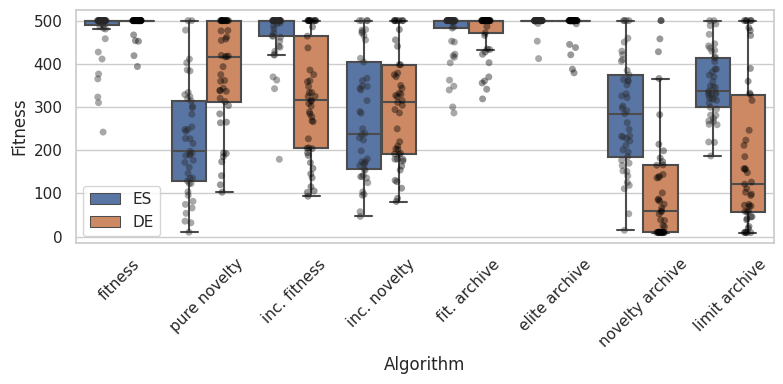

         indice           cont   fitnesses
0    101_lambda        fitness   48.675017
1    102_lambda        fitness   80.123768
2    103_lambda        fitness  -23.132908
3    104_lambda        fitness -107.148946
4    105_lambda        fitness  -99.795652
..          ...            ...         ...
715    141_diff  limit archive -389.212322
716    142_diff  limit archive -173.136445
717    143_diff  limit archive -264.016041
718    144_diff  limit archive -156.071635
719    145_diff  limit archive -331.446348

[720 rows x 3 columns]
         indice           cont   fitnesses     alg
0    101_lambda        fitness   48.675017  lambda
1    102_lambda        fitness   80.123768  lambda
2    103_lambda        fitness  -23.132908  lambda
3    104_lambda        fitness -107.148946  lambda
4    105_lambda        fitness  -99.795652  lambda
..          ...            ...         ...     ...
715    141_diff  limit archive -389.212322    diff
716    142_diff  limit archive -173.136445    diff
7

<Figure size 640x480 with 0 Axes>

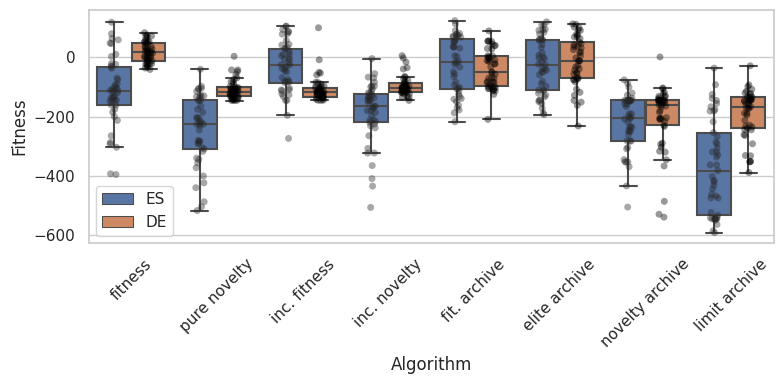

In [75]:
en = "lunarlander"
attribute = "fitnesses"
def boxplot_per_environment_containers(en, attribute):
    big_table = pd.DataFrame()
    cts = LAMBDA_CONTS
    conts = list(cts.keys())
    for cont in conts:
        values = pd.DataFrame()
        for alg in ["lambda", "diff"]:
            values_en = get_final_seed_mapped_value(en, cont, alg, names[en],  path="../Data/final/").copy()
            values_en.index = values_en.index +"_"+ str(alg)
            values = pd.concat([values, values_en])
        table = values[attribute]
        table.name = cont
        big_table = pd.concat([big_table, table], axis=1)
    big_table.columns = [container_naming[col] for col in big_table.columns]
    big_table.index.name = "indice"
    big_table = big_table.reset_index()
    big_table = big_table.melt(
    id_vars = "indice",
    var_name="cont",
    value_name=attribute
    )
    print(big_table)
    big_table["alg"]=big_table["indice"].str.split("_").str[1]
    print(big_table)
    sns.set_theme(style="whitegrid")

    fig, ax = plt.subplots(figsize=(8, 4))

    sns.boxplot(
        data=big_table,
        y = attribute,
        x = "cont",
        showfliers=False,
        hue="alg",
        ax=ax
    )

    
    sns.stripplot(
        data=big_table,
        x="cont",
        y=attribute,
        hue="alg",
        dodge=True,
        alpha=0.4,
        color="black",
        ax=ax
    )
    handles, labels = ax.get_legend_handles_labels()
    labels = [alg_naming[lab] for lab in labels]
    ax.legend(handles[:len(big_table["alg"].unique())],
          labels[:len(big_table["alg"].unique())])
    ax.set_xlabel("Algorithm")
    ax.set_ylabel("Fitness" if attribute == "fitnesses" else "Diversity")
    return ax

attr = "fitnesses"
for en in ENIVROMENTS:
    plt.figure()
    ax =boxplot_per_environment_containers(en, attr)
    plt.xticks(rotation=45)
    plt.tight_layout()
    path = "../Docs/vzor-dp/img/"

    plt.savefig(path + f"finalbox_{en}_{alg}_{attr}.pdf", bbox_inches="tight")

    plt.show()

In [76]:

friedman_test_total_containers( datasets, "fitnesses")

FriedmanchisquareResult(statistic=634.5897046646428, pvalue=8.631819907854839e-133)

## Groups

In [77]:
groups = {
    "novelty_group":[
        "novelty", "novelty_archiving", "novelty_limit"
    ],
    "fitness_group":[
        "fitness", "fit_archiving", "elite_archiving"
    ],
    "combine_group":[
        "add_novelty", "sub_novelty"
    ]
}

group_naming ={
    "fitness_group": "fitness obj.",
    "combine_group": "combination obj.",
    "novelty_group": "novelty obj.",
}

In [78]:
def group_integrity_to_latex(dk):
    dk = dk.copy()

    dk[("group","group")] = dk[("group","group")].apply(lambda x: group_naming[x])
    print(isinstance(dk.columns, pd.MultiIndex))

    COLUMN_NAMES = {
        "direction":"${HL}_{Total}$",
        "direction_diff":"${HL}_{DE}$",
        "direction_lambda":"${HL}_{ES}$",
        "hoch_p": "$p_{Hoch}$",
        "holm_p": "$p_{Holm}$",
        "wilcoxon_T": "$W_T$",
        "contestant1": "A",
        "contestant2": "B",
        "p_adj": "$p_{Total}$",
        "p_adj_diff": "$p_{DE}$",
        "p_adj_lambda": "$p_{ES}$",
        "group":"group name"

    }

    new_columns = pd.MultiIndex.from_tuples([(col[0], COLUMN_NAMES[col[1]]) if col[1] in COLUMN_NAMES else col for col in dk.columns])
    print(new_columns)
    dk.columns = new_columns

    latex = dk.to_latex(
        index=False,
        escape=False,
        multicolumn=True,
        multirow=True,
        formatters= [fmt if col[1].startswith("$p") else fmt_no_highlight for col in dk.columns],
        column_format="cc|ccc|ccc"
    )
    return latex

In [79]:
def grouped_intra_per_environment(en,  groups, attribute):
    big_table = pd.DataFrame()
    for g in groups:
        table = pd.DataFrame()
        for cont in groups[g]:
            print(cont)
            values = pd.DataFrame()
            for alg in ["lambda", "diff"]:
                values_en = get_final_seed_mapped_value(en, cont, alg, names[en], path="../Data/final/").copy()
                values_en.index = values_en.index +"_"+ str(alg)
                values = pd.concat([values, values_en])
            table = pd.concat([table,values[attribute]], axis=1)
        extract = table.median(axis=1)
        extract.name = g
        big_table = pd.concat([big_table, extract], axis=1)
    return friedmanchisquare(*[big_table[col] for col in big_table.columns])

def grouped_iner_per_environment(en,  groups, attribute):
    tests = []
    for g in groups:
        table = pd.DataFrame()
        for cont in groups[g]:
            print(cont)
            values = pd.DataFrame()
            for alg in ["lambda", "diff"]:
                values_en = get_final_seed_mapped_value(en, cont, alg, names[en], path="../Data/final/").copy()
                values_en.index = values_en.index +"_"+ str(alg)
                values = pd.concat([values, values_en])
            v = values[attribute]
            v.name = cont
            table = pd.concat([table,v], axis=1)
        samples = [table[col] for col in table.columns]
        if len(samples) < 3:
            stats, p = wilcoxon(samples[0], samples[1])
            tests.append((g, "wilcoxon", stats, p))
        else:
            stats, p = friedmanchisquare(*samples)
            tests.append((g, "friedman", stats, p))

    return pd.DataFrame(tests, columns=["group","test", "statistic", "p_adj" ])   

def grouped_iner_per_alg_environment(en, alg,  groups, attribute):
    tests = []
    for g in groups:
        table = pd.DataFrame()
        for cont in groups[g]:
            values = get_final_seed_mapped_value(en, cont, alg, names[en], path="../Data/final/").copy()
            values.index = values.index +"_"+ str(alg)
            v = values[attribute]
            v.name = cont
            table = pd.concat([table,v], axis=1)
        samples = [table[col] for col in table.columns]
        if len(samples) < 3:
            stats, p = wilcoxon(samples[0], samples[1])
            tests.append((g, "wilcoxon", stats, p))
        else:
            stats, p = friedmanchisquare(*samples)
            tests.append((g, "friedman", stats, p))

    return pd.DataFrame(tests, columns=["group","test", "statistic", "p_adj" ]) 
def group_itergrity_table_env(en, attr):
    df1 = grouped_iner_per_environment(en, groups=groups, attribute=attr)
    df2 = grouped_iner_per_alg_environment(en,"diff", groups=groups, attribute=attr)
    df3 = grouped_iner_per_alg_environment(en,"lambda", groups=groups, attribute=attr)
    dft = df1.merge(df2, on=["group", "test"], 
            suffixes=("", "_diff")).merge(df3, on=["group", "test"], 
            suffixes=("", "_lambda"))
    dft = dft[["group", "test", "p_adj", "p_adj_diff", "p_adj_lambda"]]
    new_index = pd.MultiIndex.from_tuples([
        ("group", "group"),
        ("test", "test"),
        (env_naming[en], "p_adj"),
        (env_naming[en], "p_adj_diff"),
        (env_naming[en], "p_adj_lambda")]
    )
    dft.columns = new_index
    return dft

def group_integrity_table(attr):
    ll = group_itergrity_table_env("lunarlander", attr)
    ct = group_itergrity_table_env("cartpole", attr)
    return ll.merge(ct, on=[("group","group"), ("test","test")])

fit_table = group_integrity_table("fitnesses")
novelty_table = group_integrity_table("behaviors")

fit_tab_lx = group_integrity_to_latex(fit_table)
nov_tab_lx = group_integrity_to_latex(novelty_table)

with open("../Docs/vzor-dp/tables/fit_group_integrity.tex", "w") as f:
    f.write(fit_tab_lx)

with open("../Docs/vzor-dp/tables/div_group_integrity.tex", "w") as f:
    f.write(nov_tab_lx)

print(fit_tab_lx)

novelty
novelty_archiving
novelty_limit
fitness
fit_archiving
elite_archiving
add_novelty
sub_novelty
novelty
novelty_archiving
novelty_limit
fitness
fit_archiving
elite_archiving
add_novelty
sub_novelty
novelty
novelty_archiving
novelty_limit
fitness
fit_archiving
elite_archiving
add_novelty
sub_novelty
novelty
novelty_archiving
novelty_limit
fitness
fit_archiving
elite_archiving
add_novelty
sub_novelty
True
MultiIndex([(       'group',  'group name'),
            (        'test',        'test'),
            ('Lunar Lander', '$p_{Total}$'),
            ('Lunar Lander',    '$p_{DE}$'),
            ('Lunar Lander',    '$p_{ES}$'),
            (    'CartPole', '$p_{Total}$'),
            (    'CartPole',    '$p_{DE}$'),
            (    'CartPole',    '$p_{ES}$')],
           )
True
MultiIndex([(       'group',  'group name'),
            (        'test',        'test'),
            ('Lunar Lander', '$p_{Total}$'),
            ('Lunar Lander',    '$p_{DE}$'),
            ('Lunar Lander',

/home/schkliba/.pyenv/versions/prometheus/lib/python3.10/site-packages/scipy/stats/_morestats.py:3337: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/home/schkliba/.pyenv/versions/prometheus/lib/python3.10/site-packages/scipy/stats/_morestats.py:3337: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/home/schkliba/.pyenv/versions/prometheus/lib/python3.10/site-packages/scipy/stats/_morestats.py:3337: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/tmp/ipykernel_76612/3808921929.py:27: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler

In [80]:
def grouped_inter_per_environment(en,  groups, attribute):
    big_table = pd.DataFrame()
    for g in groups:
        table = pd.DataFrame()
        for cont in groups[g]:
            print(cont)
            values = pd.DataFrame()
            for alg in ["lambda", "diff"]:
                values_en = get_final_seed_mapped_value(en, cont, alg, names[en], path="../Data/final/").copy()
                values_en.index = values_en.index +"_"+ str(alg)
                values = pd.concat([values, values_en])
            table = pd.concat([table,values[attribute]], axis=1)
        extract = table.median(axis=1)
        extract.name = g
        big_table = pd.concat([big_table, extract], axis=1)
    tests = []
    for duelants in combinations(list(groups.keys()), 2):
        selection1 = big_table[duelants[0]]
        selection2 = big_table[duelants[1]]
        stats, p = wilcoxon(selection1, selection2)
        direction = hodges_lehmann_paired(selection1, selection2)
        tests.append((duelants[0], duelants[1], stats, p, direction))
    return pd.DataFrame(tests, columns=["contestant1", "contestant2", "wilcoxon_T", "p", "direction"])

def grouped_inter_per_alg_environment(en, alg,  groups, attribute):
    big_table = pd.DataFrame()
    for g in groups:
        table = pd.DataFrame()
        for cont in groups[g]:
            values = get_final_seed_mapped_value(en, cont, alg, names[en], path="../Data/final/").copy()
            values.index = values.index +"_"+ str(alg)
            #values = pd.concat([values, values_en])
            table = pd.concat([table,values[attribute]], axis=1)
        extract = table.median(axis=1)
        extract.name = g
        big_table = pd.concat([big_table, extract], axis=1)
    tests = []
    for duelants in combinations(list(groups.keys()), 2):
        selection1 = big_table[duelants[0]]
        selection2 = big_table[duelants[1]]
        stats, p = wilcoxon(selection1, selection2)
        direction = hodges_lehmann_paired(selection1, selection2)
        tests.append((duelants[0], duelants[1], stats, p, direction))
    return pd.DataFrame(tests, columns=["contestant1", "contestant2", "wilcoxon_T", "p", "direction"])

def wilcox_group_table_create(en, groups, attr):
    wilcoxon_total = prepare_join(apply_corrections(grouped_inter_per_environment(en,groups, attr)))
    wilcoxon_diff = prepare_join(apply_corrections(grouped_inter_per_alg_environment(en,"diff",groups, attr)))
    wilcoxon_lambda = prepare_join(apply_corrections(grouped_inter_per_alg_environment(en,"lambda",groups, attr)))

    return wilcoxon_total.merge(
        wilcoxon_diff, 
        on=["contestant1", "contestant2"], 
        suffixes=("", "_diff")
        ).merge(
            wilcoxon_lambda,
            on=["contestant1", "contestant2"], 
            suffixes=("", "_lambda")
        )

l = wilcoxon_to_latex(wilcox_group_table_create("lunarlander", groups, "fitnesses"), group_naming)
c = wilcoxon_to_latex(wilcox_group_table_create("cartpole", groups, "fitnesses"), group_naming)

with open("../Docs/vzor-dp/tables/lunarlander_wilcoxon_group_fit_conts.tex", "w") as f:
     f.write(l)

with open("../Docs/vzor-dp/tables/cartpole_wilcoxon_group_fit_conts.tex", "w") as f:
     f.write(c)

l = wilcoxon_to_latex(wilcox_group_table_create("lunarlander", groups, "behaviors"), group_naming)
c = wilcoxon_to_latex(wilcox_group_table_create("cartpole", groups, "behaviors"), group_naming)

with open("../Docs/vzor-dp/tables/lunarlander_wilcoxon_group_div_conts.tex", "w") as f:
     f.write(l)

with open("../Docs/vzor-dp/tables/cartpole_wilcoxon_group_div_conts.tex", "w") as f:
     f.write(c)

novelty
novelty_archiving
novelty_limit
fitness
fit_archiving
elite_archiving
add_novelty
sub_novelty


/tmp/ipykernel_76612/3229357972.py:30: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex = dk.to_latex(


novelty
novelty_archiving
novelty_limit
fitness
fit_archiving
elite_archiving
add_novelty
sub_novelty


/home/schkliba/.pyenv/versions/prometheus/lib/python3.10/site-packages/scipy/stats/_morestats.py:3337: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/home/schkliba/.pyenv/versions/prometheus/lib/python3.10/site-packages/scipy/stats/_morestats.py:3337: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/tmp/ipykernel_76612/3229357972.py:30: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex = dk.to_latex(


novelty
novelty_archiving
novelty_limit
fitness
fit_archiving
elite_archiving
add_novelty
sub_novelty


/home/schkliba/.pyenv/versions/prometheus/lib/python3.10/site-packages/scipy/stats/_morestats.py:3337: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/tmp/ipykernel_76612/3229357972.py:30: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex = dk.to_latex(


novelty
novelty_archiving
novelty_limit
fitness
fit_archiving
elite_archiving
add_novelty
sub_novelty


/tmp/ipykernel_76612/3229357972.py:30: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex = dk.to_latex(


# Hyperparameters Optuna

## Lambda

### Cartpole

cross_method = trial.suggest_categorical("crossmethod", ["uniform", "mean"])
l = trial.suggest_categorical("lambda",[10,20,30])
m = trial.suggest_categorical("mu",[10,20,30])
mr = trial.suggest_float("mutation_rate", 0, 0.1, step=0.01)
cr = trial.suggest_float("cross_rate", 0.3, 1, step=0.1)
sigma = trial.suggest_float("sigma", 0.5, 2, step=0.5)
archiving = trial.suggest_int("archiving_period", 2, 5)
archive_batch = trial.suggest_int("archive_batch", 1, 5)
limit = trial.suggest_float("limit", 200, 300, step=10)
fit_w = trial.suggest_float("start_fit_w", 0.2, 0.7, step=0.1)
decay = trial.suggest_float("decay", 0.5, 5, step=0.5)
cross_uni = None
if cross_method == "uniform":
    cross_uni = trial.suggest_float("cross", 0.1, 0.9, step=0.1)




In [81]:
import pandas as pd
en = "cartpole"
alg = "lambda"
import pandas as pd

cols = pd.MultiIndex.from_product(
    [[en], ["Min", "Max", "Step"]]
)

df = pd.DataFrame([
    ["uniform", "mean", "-"],
    [10, 30, 10],
    [10, 30, 10],
    [0.00, 0.10, 0.01],
    [0.3, 1.0, 0.1],
    [0.5, 2.0, 0.5],
    [2, 5, 1],
    [1, 5, 1],
    [200, 300, 10],
    [0.2, 0.7, 0.1],
    [0.5, 5.0, 0.5],
    [0.1, 0.9, 0.1],
],
index=[
    "cross_method",
    "lambda",
    "mu",
    "mutation_rate",
    "cross_rate",
    "sigma",
    "archiving_period",
    "archive_batch",
    "limit",
    "start_fit_w",
    "decay",
    "cross*"
],
columns=cols)
df_c = df#.reset_index().rename(columns={"index": "Parameter"})

# df.to_csv(f"./Data/bayes_protocol/params_{alg}.csv")
# latex = df.to_latex(
#     index=False,
#     escape=True,
#     float_format=lambda x: f"{x:.3f}",
#     column_format="l" + "c" * len(df.columns)
# )
# print(latex)

### Lunar Lander

cross_method = trial.suggest_categorical("crossmethod", ["uniform", "mean"])
l = trial.suggest_categorical("lambda",[ 40, 50, 60, 70])
m = trial.suggest_categorical("mu",[40, 50, 60, 70])
mr = trial.suggest_float("mutation_rate", 0, 0.5, step=0.01)
cr = trial.suggest_float("cross_rate", 0.3, 1, step=0.1)
sigma = trial.suggest_float("sigma", 0.5, 3, step=0.5)
fit_w = trial.suggest_float("start_fit_w", 0.2, 1, step=0.1)
decay = trial.suggest_float("decay", 0.5, 5, step=0.5)
archiving = trial.suggest_int("archiving_period", 2, 5)
archive_batch = trial.suggest_int("archive_batch", 1, 5)
limit = trial.suggest_float("limit", -200, -50, step=10)

cross_uni = None
if cross_method == "uniform":
    cross_uni = trial.suggest_float("cross", 0.1, 0.9, step=0.1)

In [82]:
en="lunarlander"
columns = pd.MultiIndex.from_product([[en], ["Min", "Max", "Step"]])

df = pd.DataFrame(
    [
        ["uniform", "mean", "-"],
        [40, 70, 10],
        [40, 70, 10],
        [0.00, 0.50, 0.01],
        [0.3, 1.0, 0.1],
        [0.5, 3.0, 0.5],
        [0.2, 1.0, 0.1],
        [0.5, 5.0, 0.5],
        [2, 5, 1],
        [1, 5, 1],
        [-200, -50, 10],
        [0.1, 0.9, 0.1],
    ],
    index=[
        "cross_method",
        "lambda",
        "mu",
        "mutation_rate",
        "cross_rate",
        "sigma",
        "start_fit_w",
        "decay",
        "archiving_period",
        "archive_batch",
        "limit",
        "cross*",
    ],
    columns=columns,
    )
df_l = df
#df_l = df.reset_index().rename(columns={"index": "Parameter"})

df_total = df_c.join(df_l)
df = df_total.reset_index().rename(columns={"index": "Parameter"})

df.to_csv(f"../Data/bayes_protocol/params_{alg}.csv")
latex = df.to_latex(
    index=False,
    escape=True,
    float_format=lambda x: f"{x:.2f}",
    column_format="l" + "c" * len(df.columns)
)
print(latex)

\begin{tabular}{lccccccc}
\toprule
       Parameter & \multicolumn{3}{l}{cartpole} & \multicolumn{3}{l}{lunarlander} \\
                 &      Min &  Max & Step &         Min &  Max & Step \\
\midrule
    cross\_method &  uniform & mean &    - &     uniform & mean &    - \\
          lambda &       10 &   30 &   10 &          40 &   70 &   10 \\
              mu &       10 &   30 &   10 &          40 &   70 &   10 \\
   mutation\_rate &     0.00 & 0.10 & 0.01 &        0.00 & 0.50 & 0.01 \\
      cross\_rate &     0.30 & 1.00 & 0.10 &        0.30 & 1.00 & 0.10 \\
           sigma &     0.50 & 2.00 & 0.50 &        0.50 & 3.00 & 0.50 \\
archiving\_period &        2 &    5 &    1 &           2 &    5 &    1 \\
   archive\_batch &        1 &    5 &    1 &           1 &    5 &    1 \\
           limit &      200 &  300 &   10 &        -200 &  -50 &   10 \\
     start\_fit\_w &     0.20 & 0.70 & 0.10 &        0.20 & 1.00 & 0.10 \\
           decay &     0.50 & 5.00 & 0.50 &        0.50 & 5.0

/tmp/ipykernel_76612/3726099999.py:42: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex = df.to_latex(


## Differential

### Carpole

l = trial.suggest_categorical("pop",[5,10,15,20])
mr = trial.suggest_float("mutation_rate", 0, 1, step=0.1)
cr = trial.suggest_float("cross_rate", 0.3, 1, step=0.1)
archiving = trial.suggest_int("archiving_period", 2, 5)
archive_batch = trial.suggest_int("archive_batch", 1, 5)
limit = trial.suggest_float("limit", 200, 300, step=10)
fit_w = trial.suggest_float("start_fit_w", 0.2, 1, step=0.1)
decay = trial.suggest_float("decay", 0.5, 5, step=0.5)


In [83]:
en = "cartpole"
columns = pd.MultiIndex.from_product([[en], ["Min", "Max", "Step"]])

df = pd.DataFrame(
    [
        [5, 20, 5],          # pop
        [0.0, 1.0, 0.1],     # mutation_rate
        [0.3, 1.0, 0.1],     # cross_rate
        [2, 5, 1],           # archiving_period
        [1, 5, 1],           # archive_batch
        [200, 300, 10],      # limit
        [0.2, 1.0, 0.1],     # start_fit_w
        [0.5, 5.0, 0.5],     # decay
    ],
    index=[
        "pop",
        "mutation_rate",
        "cross_rate",
        "archiving_period",
        "archive_batch",
        "limit",
        "start_fit_w",
        "decay",
    ],
    columns=columns
)

df_c = df

### Lunar lander

l = trial.suggest_categorical("lambda",[ 40, 50, 60, 70])
mr = trial.suggest_float("mutation_rate", 0, 1, step=0.1)
cr = trial.suggest_float("cross_rate", 0.3, 1, step=0.1)
archiving = trial.suggest_int("archiving_period", 2, 5)
archive_batch = trial.suggest_int("archive_batch", 1, 5)
limit = trial.suggest_float("limit", -200, -50, step=10)
fit_w = trial.suggest_float("start_fit_w", 0.2, 1, step=0.1)
decay = trial.suggest_float("decay", 0.5, 5, step=0.5)

In [84]:
en = "lunarlander"
alg = "diff"
columns = pd.MultiIndex.from_product([[en], ["Min", "Max", "Step"]])

df = pd.DataFrame(
    [
        [40, 70, 10],        # pop
        [0.0, 1.0, 0.1],     # mutation_rate
        [0.3, 1.0, 0.1],     # cross_rate
        [2, 5, 1],           # archiving_period
        [1, 5, 1],           # archive_batch
        [-200, -50, 10],     # limit
        [0.2, 1.0, 0.1],     # start_fit_w
        [0.5, 5.0, 0.5],     # decay
    ],
    index=[
        "pop",
        "mutation_rate",
        "cross_rate",
        "archiving_period",
        "archive_batch",
        "limit",
        "start_fit_w",
        "decay",
    ],
    columns=columns
)
df_l = df
df_total = df_c.join(df_l)
df = df_total.reset_index().rename(columns={"index": "Parameter"})

df.to_csv(f"../Data/bayes_protocol/params_{alg}.csv")
latex = df.to_latex(
    index=False,
    escape=True,
    float_format=lambda x: f"{x:.2f}",
    column_format="l" + "c" * len(df.columns)
)
print(latex)


\begin{tabular}{lccccccc}
\toprule
       Parameter & \multicolumn{3}{l}{cartpole} & \multicolumn{3}{l}{lunarlander} \\
                 &      Min &    Max &  Step &         Min &    Max &  Step \\
\midrule
             pop &     5.00 &  20.00 &  5.00 &       40.00 &  70.00 & 10.00 \\
   mutation\_rate &     0.00 &   1.00 &  0.10 &        0.00 &   1.00 &  0.10 \\
      cross\_rate &     0.30 &   1.00 &  0.10 &        0.30 &   1.00 &  0.10 \\
archiving\_period &     2.00 &   5.00 &  1.00 &        2.00 &   5.00 &  1.00 \\
   archive\_batch &     1.00 &   5.00 &  1.00 &        1.00 &   5.00 &  1.00 \\
           limit &   200.00 & 300.00 & 10.00 &     -200.00 & -50.00 & 10.00 \\
     start\_fit\_w &     0.20 &   1.00 &  0.10 &        0.20 &   1.00 &  0.10 \\
           decay &     0.50 &   5.00 &  0.50 &        0.50 &   5.00 &  0.50 \\
\bottomrule
\end{tabular}



/tmp/ipykernel_76612/3239202418.py:33: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex = df.to_latex(


## Optuna Studies

In [85]:
import optuna
import json
def load_optuna_study(en,alg,container):
    with open("../relevant_studies.json", "r") as f:
        relevant_study_names = json.load(f)
    storage = f"sqlite:///../Data/optuna/{en}/{container}/{alg}.db"
    study_name = relevant_study_names[container][alg][en]

    new_study = optuna.load_study(study_name=study_name,storage=storage)

    return new_study
rows = []
for en in ["cartpole", "lunarlander"]:
    for alg in ["lambda", "diff"]:
        for container in LAMBDA_CONTS:
            study = load_optuna_study(en,alg,container)
            row = (env_naming[en], alg_naming[alg], container_naming[container], study.best_value, len(study.trials), len(study.best_trials))
            rows.append(row)

data = pd.DataFrame(data = rows, columns=["environment", "alg.", "container", "Best Score", "Trials", "Best Trials"])
data =data.pivot(
    index=["environment","container"],
    columns= ["alg."],
    values=["Best Score", "Trials", "Best Trials"]
)
latex = data.to_latex(
    index=True,
    escape=True,
    float_format=lambda x: f"{int(x)}",
    column_format="ll|" + "r" * len(df.columns)
)
print(latex)
with open("../Docs/vzor-dp/tables/optuna_table.tex", "w") as f:
     f.write(latex)

\begin{tabular}{ll|rrrrrrr}
\toprule
             & {} & \multicolumn{2}{l}{Best Score} & \multicolumn{2}{l}{Trials} & \multicolumn{2}{l}{Best Trials} \\
             & alg. &         DE &  ES &     DE &  ES &          DE & ES \\
environment & container &            &     &        &     &             &    \\
\midrule
CartPole & elite archive &        500 & 500 &    150 & 200 &          20 & 42 \\
             & fit. archive &        500 & 500 &    192 & 190 &          46 & 30 \\
             & fitness &        500 & 500 &    100 & 100 &          31 & 15 \\
             & inc. fitness &        500 & 500 &    160 & 160 &          71 & 27 \\
             & inc. novelty &        500 & 500 &    160 & 160 &          62 & 43 \\
             & limit archive &        500 & 500 &    150 & 175 &          33 & 27 \\
             & novelty archive &        500 & 500 &    195 & 195 &          18 & 26 \\
             & pure novelty &        500 & 500 &    150 & 150 &          76 & 22 \\
Lunar Lander 

/tmp/ipykernel_76612/3849233198.py:26: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex = data.to_latex(


# Generations Results

In [86]:
carpole_dict = {
    "sub_novelty":{
        "lambda": 20,
        "diff":40
    },
    "add_novelty":{
        "diff": 20,
        "lambda": 15
    },
    "novelty":{
        "lambda":25,
        "diff": 40
    },
    "fitness":{
        "diff": 10,
        "lambda": 15
    },
    "fit_archiving":{
        "diff": 25,
        "lambda": 35
    },
    "elite_archiving":{
        "lambda": 20,
        "diff": 10
    },
    "novelty_limit":{
        "lambda": 20,
        "diff": 20
    },
    "novelty_archiving":{
        "diff": 20,
        "lambda": 20
    }
}
lunarlander = {
    "fitness":{
        "diff": 35,
        "lambda": 25
    },
    "novelty":{
        "lambda": 10,
        "diff": 15
    },
    "fit_archiving":{
        "diff": 80,
        "lambda": 15,
    },
    "add_novelty":{
        "lambda": 15,
        "diff":15
    },
    "sub_novelty":{
        "lambda": 25,
        "diff": 25
    },
    "novelty_archiving":{
        "diff": 25,
        "lambda": 60
    },
    "elite_archiving":{
        "lambda":15,
        "diff": 60,
    },
    "novelty_limit":{
        "lambda":25,
        "diff": 25
    }
}

In [87]:
luna = pd.DataFrame(lunarlander).T
cartpole = pd.DataFrame(carpole_dict).T
luna_new_columns = [alg_naming[col] if col in alg_naming else col for col in luna.columns]
cart_new_columns = [alg_naming[col] if col in alg_naming else col for col in luna.columns]

luna.columns = pd.MultiIndex.from_product([["Lunar Lander"], luna_new_columns])
cartpole.columns = pd.MultiIndex.from_product([["CartPole"], cart_new_columns])
gens_table = pd.concat([luna, cartpole], axis=1)
index = [container_naming[col] if col in container_naming else col for col in gens_table.index]
gens_table.index = index
latex = gens_table.to_latex(
        index=True,
        escape=False,
        column_format="l" + "c" * len(gens_table.columns)
    )
print(latex)

\begin{tabular}{lcccc}
\toprule
{} & \multicolumn{2}{l}{Lunar Lander} & \multicolumn{2}{l}{CartPole} \\
{} &           DE &  ES &       DE &  ES \\
\midrule
fitness         &           35 &  25 &       15 &  10 \\
pure novelty    &           15 &  10 &       25 &  40 \\
fit. archive    &           80 &  15 &       35 &  25 \\
inc. fitness    &           15 &  15 &       15 &  20 \\
inc. novelty    &           25 &  25 &       20 &  40 \\
novelty archive &           25 &  60 &       20 &  20 \\
elite archive   &           60 &  15 &       20 &  10 \\
limit archive   &           25 &  25 &       20 &  20 \\
\bottomrule
\end{tabular}



/tmp/ipykernel_76612/1131492275.py:11: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex = gens_table.to_latex(


In [88]:
def table_to_latex(dk):
    dk = dk.replace(["NaN", "nan", None], np.nan)
    new_columns = [hyperparameter_naming[col] if col in hyperparameter_naming else col for col in dk.columns]
    dk.columns = new_columns
    index = [container_naming[col] if col in container_naming else col for col in dk.index]
    dk.index = index
    dk=dk.fillna("-")
    if "method" in dk.columns:
        dk["method"] = dk["method"].apply(lambda x: "A" if x =="mean" else "U")
    latex = dk.to_latex(
        index=True,
        escape=False,
        formatters= [fmt] * len(dk.columns),
        column_format="l" + "c" * len(dk.columns)
    )
    return latex